# Adhoc: general_agreement_simple_v2 — sentiment exploration

Quick look at the v2 zero-shot cross-sector agreement prompt run on the main-base corpus (981 docs, 2015–2023). v2 changes vs v1:
- New `Agreement_Other` score (-5..5) + `Other_Sector` disagreement-area list.
- System prompt explicitly weights policy-vs-outlook agreement and warns about diplomatic language inflation.

**Inputs**
- `/data/home/xiong/data/Fund/CSR/Tractions/output/adhoc/general_agreement_v2/df_documents_general_v2.csv` — raw v2 output (one row per doc, integer scores -5..5 with 99 = insufficient info)
- `/data/home/xiong/data/Fund/CSR/Tractions/output/main_base/df_aiv.csv` — for `Primary Country Code` + `Year from title` lookup
- `src/Traction/docs/reference/country_meta_info.xlsx` — for ISO3 → income-group mapping
- (optional) `/data/home/xiong/data/Fund/CSR/Tractions/output/main_base/df_documents_general.csv` — v1 output, for side-by-side comparison

**Outputs (in-notebook only):**
1. Overall score distribution per sector (histograms).
2. Mean score by year × income group (line charts).
3. v1 vs v2 side-by-side mean for the overall `Agreement_General`.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_TRACTION = Path('/data/home/xiong/dev/Fund_ISR/src/Traction')
if str(_TRACTION) not in sys.path:
    sys.path.insert(0, str(_TRACTION))
if str(_TRACTION / 'post_estimate_analysis') not in sys.path:
    sys.path.insert(0, str(_TRACTION / 'post_estimate_analysis'))

import data_vis_utils as dv

V2_PATH = Path('/data/home/xiong/data/Fund/CSR/Tractions/output/adhoc/general_agreement_v2/df_documents_general_v2.csv')
V1_PATH = Path('/data/home/xiong/data/Fund/CSR/Tractions/output/main_base/df_documents_general.csv')
AIV_PATH = Path('/data/home/xiong/data/Fund/CSR/Tractions/output/main_base/df_aiv.csv')
COUNTRY_META_PATH = _TRACTION / 'docs' / 'reference' / 'country_meta_info.xlsx'

SECTOR_COLS_V2 = ['Agreement_General', 'Agreement_Monetary', 'Agreement_Fiscal',
                  'Agreement_External', 'Agreement_Financial', 'Agreement_Real',
                  'Agreement_Other']
SECTOR_COLS_V1 = SECTOR_COLS_V2[:-1]  # v1 has no Agreement_Other

INCOME_ORDER = ['AE', 'EM', 'LIC']
INCOME_COLORS = {'AE': '#2E5C8A', 'EM': '#8EBDD6', 'LIC': '#2C9D5F'}

plt.rcParams['figure.figsize'] = (11, 6)

## 1 — Load v2 results and enrich with year + income group

v2 scores come from the inference output. Year/country come from `df_aiv.csv` (the v2 inference itself doesn't carry year). Income group joins via the country reference workbook on ISO3.

In [2]:
df_v2 = pd.read_csv(V2_PATH)
print('v2 shape:', df_v2.shape)
print('v2 cols:', list(df_v2.columns))
df_v2.head(3)

v2 shape: (981, 21)
v2 cols: ['index', 'Print ISBN', 'staff', 'buff', 'country', 'year', 'publication_date', 'id', 'Agreement_General', 'Agreement_Monetary', 'Agreement_Fiscal', 'Agreement_External', 'Agreement_Financial', 'Agreement_Real', 'Agreement_Other', 'Monetary_Sector', 'Fiscal_Sector', 'External_Sector', 'Financial_Sector', 'Real_Sector', 'Other_Sector']


,index,Print ISBN,staff,buff,country,year,publication_date,id,Agreement_General,Agreement_Monetary,...,Agreement_External,Agreement_Financial,Agreement_Real,Agreement_Other,Monetary_Sector,Fiscal_Sector,External_Sector,Financial_Sector,Real_Sector,Other_Sector
0,0,9781513500676,1. Finland has suffered three years of recessi...,17. The authorities agreed with staff on the s...,Finland,2015.0,11/17/2015,0,2,99,...,2,2,2,2,[],"[{'area': 'pace of fiscal consolidation', 'sev...",[{'area': 'extent of current account/competiti...,[{'area': 'timing of systemic risk buffer legi...,[{'area': 'growth outlook and near-term downsi...,[{'area': 'extent and speed of wage bargaining...
1,1,9781513560069,"1. Spain’s recovery has gathered speed, but un...",9. The authorities have higher forecasts for m...,Spain,2015.0,08/14/2015,1,1,99,...,1,2,2,2,[],[{'area': 'strength of fiscal consolidation an...,[{'area': 'degree of external imbalances and R...,[{'area': 'need for additional banking sector ...,[{'area': 'pace of further reforms to lift lon...,[{'area': 'timing of additional labor market r...
2,2,9781484304389,1. Aruba is a small open economy with high liv...,21. The authorities expected a stronger econom...,Kingdom of the Netherlands - Aruba,2017.0,06/15/2017,2,1,2,...,1,1,-1,-2,[],[{'area': 'additional structural fiscal measur...,[{'area': 'domestic borrowing and reserve pres...,[{'area': 'crowding out private credit from do...,"[{'area': 'growth outlook', 'severity': -2}]","[{'area': 'labor market regulation reform', 's..."


In [3]:
# Convert 99 (insufficient info) → NaN for clean aggregation.
for col in SECTOR_COLS_V2:
    if col in df_v2.columns:
        df_v2[col] = pd.to_numeric(df_v2[col], errors='coerce')
        df_v2.loc[df_v2[col] == 99, col] = np.nan

# Enrich with Primary Country Code + Year from title from df_aiv.csv
df_aiv = pd.read_csv(AIV_PATH, usecols=['Print ISBN', 'Primary Country Code', 'Year from title', 'staff_verified'])
df_aiv = df_aiv[df_aiv['staff_verified'] == True].copy()

df = df_v2.merge(df_aiv[['Print ISBN', 'Primary Country Code', 'Year from title']],
                  on='Print ISBN', how='left')
df = df.rename(columns={'Year from title': 'year_aiv'})
# Prefer the inference's own `year` column if it's present and non-null; fall back to aiv's.
df['year'] = pd.to_numeric(df.get('year', df['year_aiv']), errors='coerce').fillna(
    pd.to_numeric(df['year_aiv'], errors='coerce')).astype('Int64')
df = df.drop(columns=['year_aiv'])

# Income group via ISO3 join
country_map = pd.read_excel(COUNTRY_META_PATH)
df = df.merge(country_map[['ISO3', 'Income']], left_on='Primary Country Code', right_on='ISO3', how='left')
df = df.rename(columns={'Income': 'income_group'})
df.loc[~df['income_group'].isin(INCOME_ORDER), 'income_group'] = pd.NA

print('merged shape:', df.shape)
print('rows with year + income_group:', df[['year', 'income_group']].dropna().shape[0])
print('income group counts:', df['income_group'].value_counts(dropna=False).to_dict())
df[['Print ISBN', 'year', 'Primary Country Code', 'income_group', 'Agreement_General', 'Agreement_Other']].head(5)

merged shape: (981, 24)
rows with year + income_group: 951
income group counts: {'EM': 412, 'AE': 275, 'LIC': 264, <NA>: 30}


,Print ISBN,year,Primary Country Code,income_group,Agreement_General,Agreement_Other
0,9781513500676,2015,FIN,AE,2.0,2.0
1,9781513560069,2015,ESP,AE,1.0,2.0
2,9781484304389,2017,ABW,<NA>,1.0,-2.0
3,9781616357382,2021,MDA,LIC,4.0,5.0
4,9781484378120,2018,TTO,EM,1.0,2.0


## 2 — Overall score distribution per sector

How are the 7 sector scores spread across the corpus? Each bar shows the count of docs at each integer score from -5 to 5 (99 already converted to NaN and excluded).

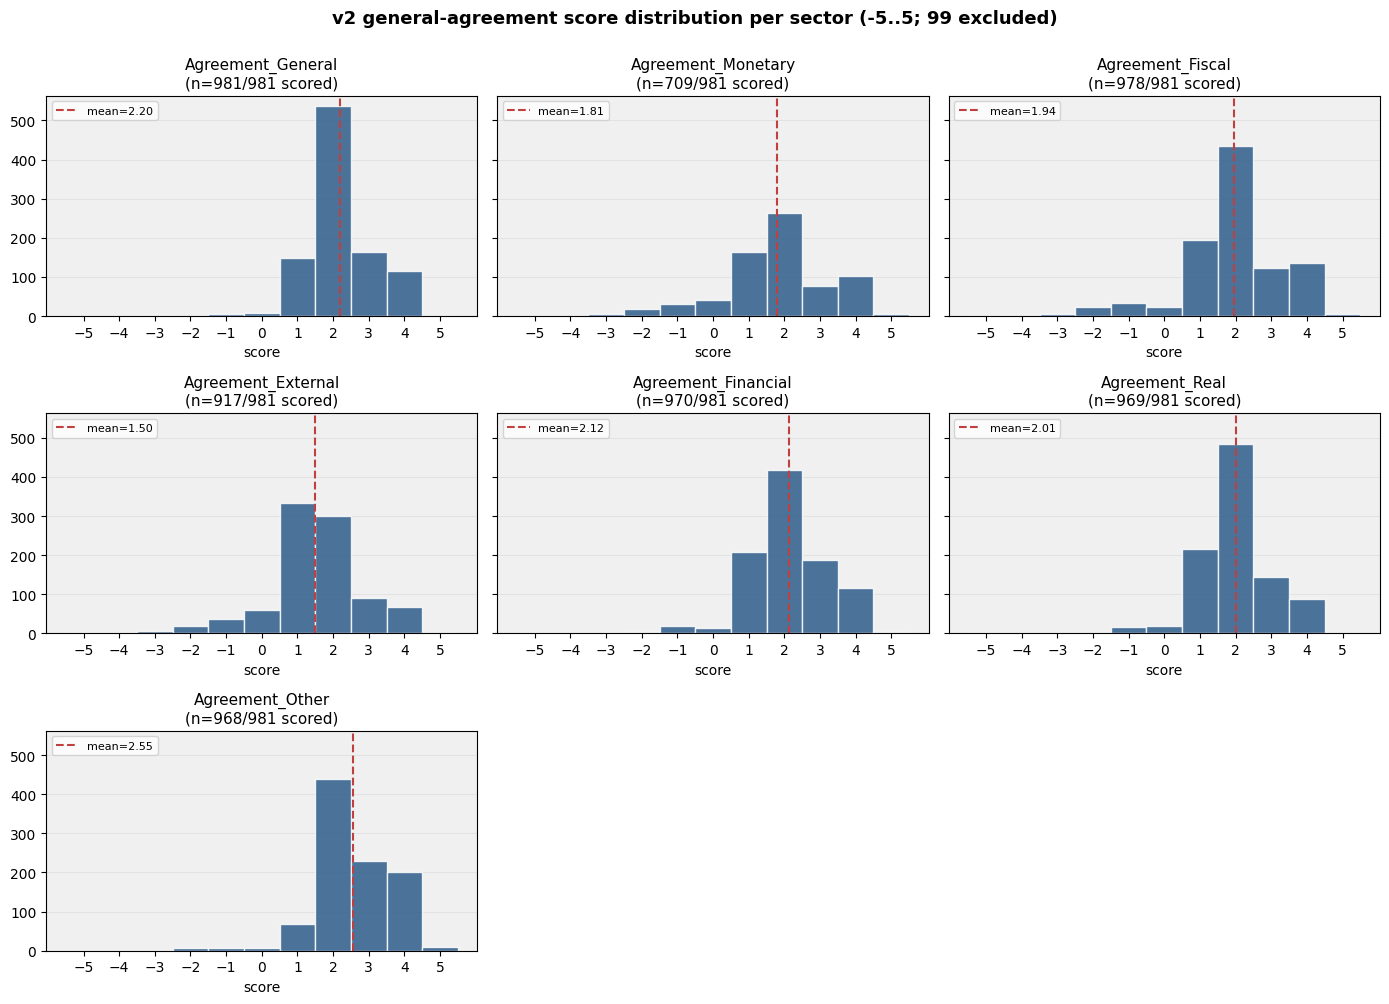

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharey=True)
axes = axes.flatten()
BINS = np.arange(-5.5, 6.5, 1.0)

for i, col in enumerate(SECTOR_COLS_V2):
    ax = axes[i]
    vals = df[col].dropna()
    ax.hist(vals, bins=BINS, color='#2E5C8A', edgecolor='white', alpha=0.85)
    mean = vals.mean()
    ax.axvline(mean, color='#C04040', linestyle='--', linewidth=1.5, label=f'mean={mean:.2f}')
    n_total = len(df)
    n_scored = len(vals)
    ax.set_title(f'{col}\n(n={n_scored}/{n_total} scored)', fontsize=11)
    ax.set_xticks(range(-5, 6))
    ax.set_xlabel('score')
    ax.legend(loc='upper left', fontsize=8)
    dv.style_axes(ax, grid_axis='y')

# Hide unused subplots
for j in range(len(SECTOR_COLS_V2), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('v2 general-agreement score distribution per sector (-5..5; 99 excluded)', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [5]:
# Compact summary table
summary = pd.DataFrame({
    'n_scored':   [df[c].notna().sum() for c in SECTOR_COLS_V2],
    'n_insuff (99→NaN)': [df.shape[0] - df[c].notna().sum() for c in SECTOR_COLS_V2],
    'mean':       [df[c].mean()   for c in SECTOR_COLS_V2],
    'median':     [df[c].median() for c in SECTOR_COLS_V2],
    'std':        [df[c].std()    for c in SECTOR_COLS_V2],
    'pct_>=3':    [(df[c] >= 3).sum() / df[c].notna().sum() * 100 for c in SECTOR_COLS_V2],
    'pct_<=-1':   [(df[c] <= -1).sum() / df[c].notna().sum() * 100 for c in SECTOR_COLS_V2],
}, index=SECTOR_COLS_V2).round(2)
summary

,n_scored,n_insuff (99→NaN),mean,median,std,pct_>=3,pct_<=-1
Agreement_General,981,0,2.20,2.0,0.97,28.54,1.02
Agreement_Monetary,709,272,1.81,2.0,1.48,26.23,7.48
Agreement_Fiscal,978,3,1.94,2.0,1.37,26.89,6.44
Agreement_External,917,64,1.50,2.0,1.33,17.45,7.20
Agreement_Financial,970,11,2.12,2.0,1.12,31.65,2.47
Agreement_Real,969,12,2.01,2.0,1.02,24.05,1.96
Agreement_Other,968,13,2.55,2.0,1.05,45.45,1.24


## 3 — Mean score by year × income group (line charts)

One line per income group, one panel per sector. The grey 'ALL' line is the unweighted corpus mean per year.

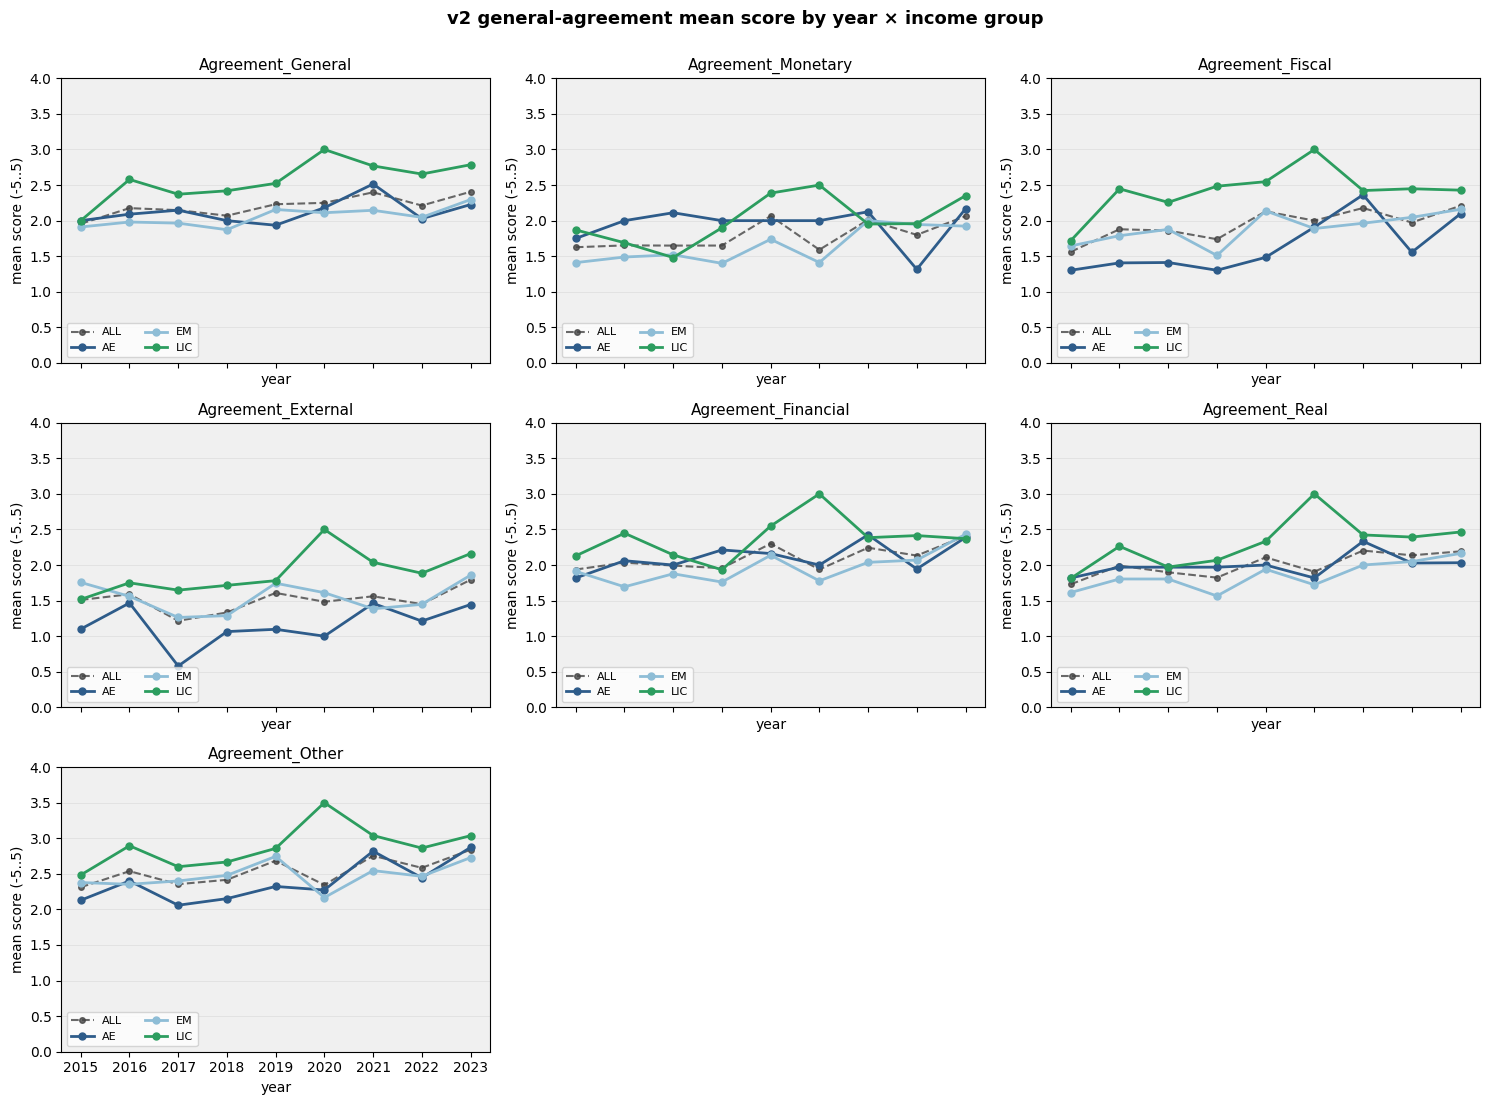

In [6]:
df_ts = df.dropna(subset=['year']).copy()
df_ts['year'] = df_ts['year'].astype(int)
df_ts = df_ts[(df_ts['year'] >= 2015) & (df_ts['year'] <= 2025)]

fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=True)
axes = axes.flatten()

for i, col in enumerate(SECTOR_COLS_V2):
    ax = axes[i]

    # ALL line — unweighted corpus mean
    all_mean = df_ts.groupby('year')[col].mean()
    ax.plot(all_mean.index, all_mean.values, color='#444444', linestyle='--', marker='o',
            markersize=4, linewidth=1.5, label='ALL', alpha=0.8)

    # Per-income-group lines
    for grp in INCOME_ORDER:
        sub = df_ts[df_ts['income_group'] == grp]
        if sub.empty:
            continue
        grp_mean = sub.groupby('year')[col].mean()
        ax.plot(grp_mean.index, grp_mean.values, color=INCOME_COLORS[grp], marker='o',
                markersize=5, linewidth=2, label=grp)

    ax.set_title(col, fontsize=11)
    ax.set_xlabel('year')
    ax.set_ylabel('mean score (-5..5)')
    ax.set_ylim(0, 4)
    ax.axhline(0, color='#888888', linewidth=0.5)
    ax.legend(loc='lower left', fontsize=8, ncol=2)
    dv.style_axes(ax, grid_axis='y')

for j in range(len(SECTOR_COLS_V2), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('v2 general-agreement mean score by year × income group', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [7]:
# Per-year sample sizes by income group (helps interpret noisy lines above)
counts_by_year = df_ts.groupby(['year', 'income_group']).size().unstack(fill_value=0).reindex(columns=INCOME_ORDER, fill_value=0)
counts_by_year['ALL'] = counts_by_year.sum(axis=1)
counts_by_year

income_group,AE,EM,LIC,ALL
year,,,,
2015,33,45,33,111
2016,33,52,38,123
2017,34,57,35,126
2018,33,47,31,111
2019,31,51,42,124
2020,11,18,2,31
2021,33,55,26,114
2022,36,43,29,108
2023,31,44,28,103


## 3b — Mean score per sector across year (single panel)

One line per sector on a shared axes — easier to read sector-level trends and inter-sector ordering at a glance. Income group is not split here (use section 3 above for the by-group view).

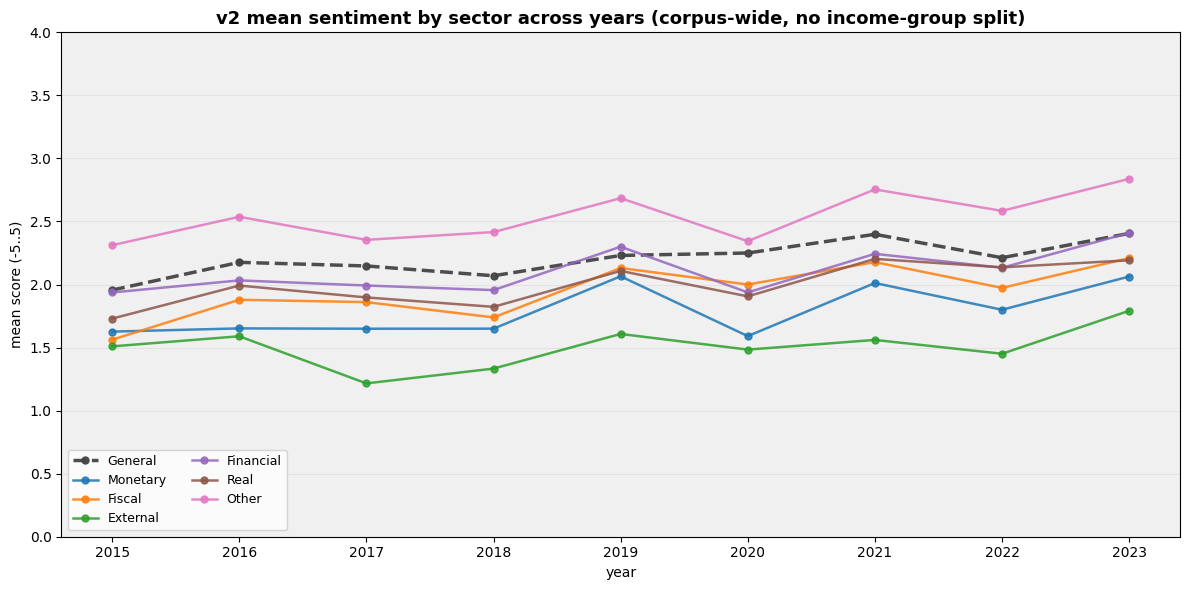

In [8]:
# Sector palette — distinct, color-blind-friendly per sector.
SECTOR_COLORS = {
    'Agreement_General':   '#444444',   # corpus baseline
    'Agreement_Monetary':  '#1F77B4',
    'Agreement_Fiscal':    '#FF7F0E',
    'Agreement_External':  '#2CA02C',
    'Agreement_Financial': '#9467BD',
    'Agreement_Real':      '#8C564B',
    'Agreement_Other':     '#E377C2',
}

fig, ax = plt.subplots(figsize=(12, 6))

for col in SECTOR_COLS_V2:
    yearly = df_ts.groupby('year')[col].mean()
    is_general = col == 'Agreement_General'
    ax.plot(yearly.index, yearly.values,
            color=SECTOR_COLORS[col],
            marker='o', markersize=5,
            linewidth=2.5 if is_general else 1.8,
            linestyle='--' if is_general else '-',
            label=col.replace('Agreement_', ''),
            alpha=0.95 if is_general else 0.85)

ax.set_title('v2 mean sentiment by sector across years (corpus-wide, no income-group split)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('year'); ax.set_ylabel('mean score (-5..5)')
ax.axhline(0, color='#888888', linewidth=0.5)
ax.set_ylim(0, 4)
ax.legend(loc='lower left', ncol=2, fontsize=9)
dv.style_axes(ax, grid_axis='y')
plt.tight_layout(); plt.show()

## 4 — v1 vs v2 side-by-side on `Agreement_General`

Quick sanity check: does v2's policy-vs-outlook reweighting and diplomatic-language disambiguation actually shift the distribution, or do the two prompts agree most of the time?

Skipped if v1 output isn't on disk.

v1 vs v2 overlap: 981 docs


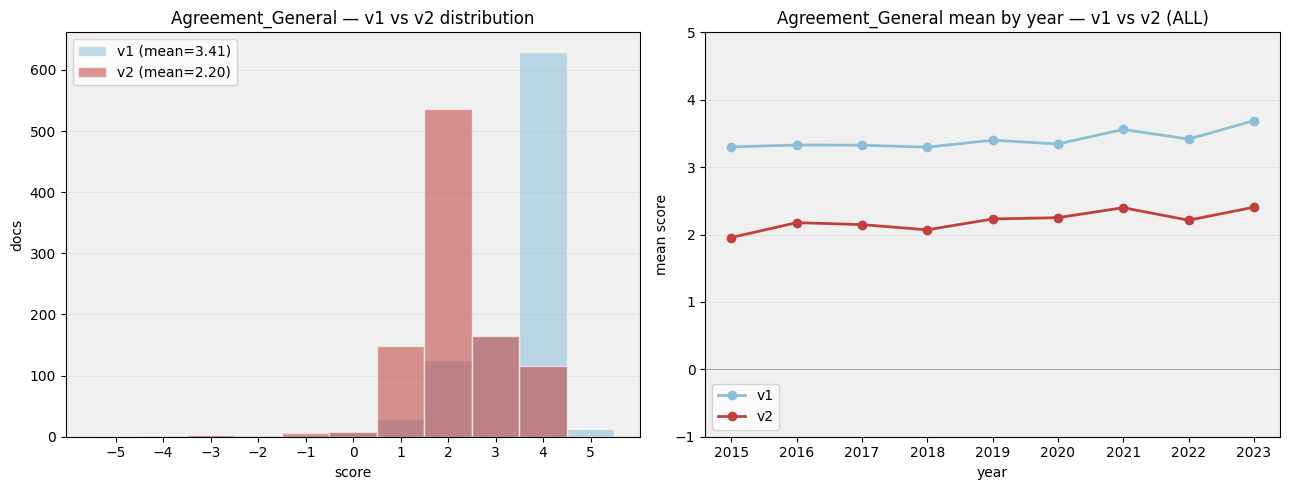


Per-doc score diff (v2 - v1):
count    981.00
mean      -1.21
std        0.91
min       -3.00
25%       -2.00
50%       -1.00
75%       -1.00
max        2.00
dtype: float64
shift direction: 22 docs scored higher in v2 | 750 lower | 209 same


In [9]:
if V1_PATH.exists():
    df_v1 = pd.read_csv(V1_PATH, usecols=['Print ISBN', 'Agreement_General'])
    df_v1['Agreement_General'] = pd.to_numeric(df_v1['Agreement_General'], errors='coerce')
    df_v1.loc[df_v1['Agreement_General'] == 99, 'Agreement_General'] = np.nan
    df_v1 = df_v1.rename(columns={'Agreement_General': 'Agreement_General_v1'})

    cmp = df[['Print ISBN', 'year', 'income_group', 'Agreement_General']].rename(
        columns={'Agreement_General': 'Agreement_General_v2'}
    ).merge(df_v1, on='Print ISBN', how='inner')
    print('v1 vs v2 overlap:', len(cmp), 'docs')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Distribution overlay
    ax = axes[0]
    BINS = np.arange(-5.5, 6.5, 1.0)
    ax.hist(cmp['Agreement_General_v1'].dropna(), bins=BINS, alpha=0.55, label=f'v1 (mean={cmp["Agreement_General_v1"].mean():.2f})', color='#8EBDD6', edgecolor='white')
    ax.hist(cmp['Agreement_General_v2'].dropna(), bins=BINS, alpha=0.55, label=f'v2 (mean={cmp["Agreement_General_v2"].mean():.2f})', color='#C04040', edgecolor='white')
    ax.set_title('Agreement_General — v1 vs v2 distribution')
    ax.set_xlabel('score'); ax.set_ylabel('docs'); ax.legend(loc='upper left')
    ax.set_xticks(range(-5, 6))
    dv.style_axes(ax, grid_axis='y')

    # Year-mean trend overlay (ALL only)
    ax = axes[1]
    cmp_ts = cmp.dropna(subset=['year']).copy()
    cmp_ts['year'] = cmp_ts['year'].astype(int)
    cmp_ts = cmp_ts[(cmp_ts['year'] >= 2015) & (cmp_ts['year'] <= 2025)]
    v1_yr = cmp_ts.groupby('year')['Agreement_General_v1'].mean()
    v2_yr = cmp_ts.groupby('year')['Agreement_General_v2'].mean()
    ax.plot(v1_yr.index, v1_yr.values, marker='o', linewidth=2, color='#8EBDD6', label='v1')
    ax.plot(v2_yr.index, v2_yr.values, marker='o', linewidth=2, color='#C04040', label='v2')
    ax.set_title('Agreement_General mean by year — v1 vs v2 (ALL)')
    ax.set_xlabel('year'); ax.set_ylabel('mean score'); ax.legend(loc='lower left')
    ax.axhline(0, color='#888888', linewidth=0.5)
    ax.set_ylim(-1, 5)
    dv.style_axes(ax, grid_axis='y')

    plt.tight_layout(); plt.show()

    print('\nPer-doc score diff (v2 - v1):')
    diff = (cmp['Agreement_General_v2'] - cmp['Agreement_General_v1']).dropna()
    print(diff.describe().round(2))
    print('shift direction:',
          f'{(diff > 0).sum()} docs scored higher in v2',
          '|', f'{(diff < 0).sum()} lower',
          '|', f'{(diff == 0).sum()} same')
else:
    print(f'v1 output not found at {V1_PATH}; skipping side-by-side comparison.')